In [167]:

%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np


###Bayesian ML functions###

from bayesian_ml import *
from packages.BayesianLinearRegression import BayesianLinearRegression
from packages.LogisticRegression import LogisticRegression
from packages.Grid2D import Grid2D
from packages.LaplaceApproximation import LaplaceApproximation
from packages.PosteriorPredictiveDistribution import PosteriorPredictiveDistribution
from packages.Hyperparameters import Hyperparameters
from packages.StationaryIsotropicKernel import StationaryIsotropicKernel
from packages.GaussianProcessRegression import GaussianProcessRegression
from packages.BayesianLinearSoftmax import BayesianLinearSoftmax
from packages.metropolis import metropolis



###Distributions###
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson

from packages.util_funs import sigmoid
from packages.util_funs import log_npdf

snb.set_theme(font_scale=1.25)

<h1>Part 1<h1>

<h1>Part 2<h1>

## Question 2.1

In [168]:
X_star = jnp.array([0, 1])

W_map =  0.74077439 * jnp.array([1, 1])
sigmoid(W_map @ X_star)

Array(0.67716517, dtype=float64, weak_type=True)

Thus the posterior predictive distribution is:

$$
Ber(y^*|0.68)
$$

## Question 2.2

In [169]:
X = jnp.array([[0,0], [1,1]])
y = jnp.array([0, 1])
model = LogisticRegression(X, y, alpha = 1/4)

This is grad [[1. 1.]]
This is grad [[0.20816557 0.20816557]]
This is grad [[0.05728246 0.05728246]]
This is grad [[0.00658784 0.00658784]]
This is grad [[0.00024925 0.00024925]]
This is grad [[1.14365712e-06 1.14365712e-06]]


In [170]:
model_log_joint_wmap = model.log_joint(W_map[:,None].T)
model_log_joint_wmap

Array([-3.77096758], dtype=float64)

## Question 2.3

In [171]:
model.grad(W_map[:,None].T)

This is grad [[0.1851936 0.1851936]]


Array([[0.1851936, 0.1851936]], dtype=float64)

In [172]:
model.hessian(W_map)

This is H [[-0.55179386 -0.30179386]
 [-0.30179386 -0.55179386]]


Array([[-0.55179386, -0.30179386],
       [-0.30179386, -0.55179386]], dtype=float64)

## Question 2.4

In [173]:
post_pred = PosteriorPredictiveDistribution(model)
model.w_MAP = W_map
post_pred.laplace.posterior_mean = W_map
post_pred.laplace.posterior_hessian = model.hessian(W_map)
post_pred.plugin_approx(X_star[:,None])

This is H [[-0.4655231 -0.2155231]
 [-0.2155231 -0.4655231]]
This is H [[-0.55179386 -0.30179386]
 [-0.30179386 -0.55179386]]


Array([0.1851936, 0.8148064], dtype=float64)

As we construct the Laplace approximation from the MAP estimate the mean of the posterior predictive distribution will be the MAP estimate and the covariance will be the hessian evaluated at the MAP.

$$
P(y^*|y,x^*) = N(y^* |
\begin{pmatrix}
0.98 \\
0.98
\end{pmatrix},

\begin{pmatrix}
2.73 & -1.27 \\
-1.27 & 2.73
\end{pmatrix}
)
$$

## Question 2.5

The problem changes from binary classification to multi class  classification and thus instead of using the bernoulli distribution I would use a poisson distribution.

<h1>Part 3<h1>

<h1>Part 4<h1>

## Question 4.1

In [174]:
m = jnp.array([-0.87, 2.13])
S = jnp.array([[0.41, 0.11], [0.11, 0.27]])

For the prior probability of $w_1 > 0$, we know that $p(w) = N(w | 0, \alpha^{-1})$ and thus the prior probability of $w_1 > 0 = 0.5$

In [175]:
1 - mvn.cdf(0, -0.87, 0.41)

np.float64(0.08711897705972571)

## Question 4.2

In [176]:
samples = np.random.normal(2.13, jnp.sqrt(0.27), size=10**6)
lower,upper = jnp.percentile(samples, jnp.array([10, 90]))
lower1, upper1 = norm.interval(0.8, 2.13, jnp.sqrt(0.27))
lower, lower1, upper, upper1

(Array(1.46285759, dtype=float64),
 np.float64(1.4640862727871946),
 Array(2.79609556, dtype=float64),
 np.float64(2.795913727212805))

## Question 4.3

In [177]:
Phi = jnp.array([1, 1])
m.T @ Phi, Phi @ S @ Phi.T

(Array(1.26, dtype=float64), Array(0.9, dtype=float64))

## Question 4.4

In [178]:
beta = 1/jnp.sqrt(2)
Phi = jnp.array([1, 1])

mu_f = Phi@m
var_f = Phi@S@Phi.T

mu_y = mu_f
var_y = var_f + 1/beta

mu_f, var_y

(Array(1.26, dtype=float64), Array(2.31421356, dtype=float64))

## Question 4.5

In [179]:
vs = jnp.array([0.38, 0.19, 0.13, 0.09])
d = 4
entropy = d / 2 + d / 2 * jnp.log(2 * jnp.pi) + 1/2 * jnp.log(jnp.linalg.det(vs * jnp.identity(4)))
entropy

Array(2.1375133, dtype=float64)


## Question 4.6

In [180]:
ms = jnp.array([-0.82, 2.37, -0.88, 0.37])
vs = jnp.array([0.38, 0.19, 0.13, 0.09])
key = random.PRNGKey(1)
ws = random.multivariate_normal(key, ms, vs * jnp.identity(4), shape=(100000, ))

preds = norm.pdf(1.0, 
                 ws[:, 0] + ws[:, 1],  # x*=1 so w1*x* = w1
                 jnp.sqrt(jnp.exp(ws[:, 2] + ws[:, 3])))
jnp.mean(preds)

Array(0.32061387, dtype=float64)

<h1>Part 5<h1>

In [193]:
theta_init = jnp.array([0,0])
tau = 1
num_params = 2
num_iter = 10**4
dis_prop = 0.1
sigma2 = 2

X_train = jnp.array([1])
y_train = jnp.array([2])
f = lambda w: w[1] * jnp.tanh(w[0] * X_train)
log_target = lambda w: jnp.sum(norm.logpdf(y_train, f(w), jnp.sqrt(sigma2))) + norm.logpdf(w[0], 0, 1) + norm.logpdf(w[1], 0, 1)
MCMC = metropolis(log_target, num_params, tau, num_iter, theta_init, seed=0, dis_prop=dis_prop)

Acceptance ratio: 0.54


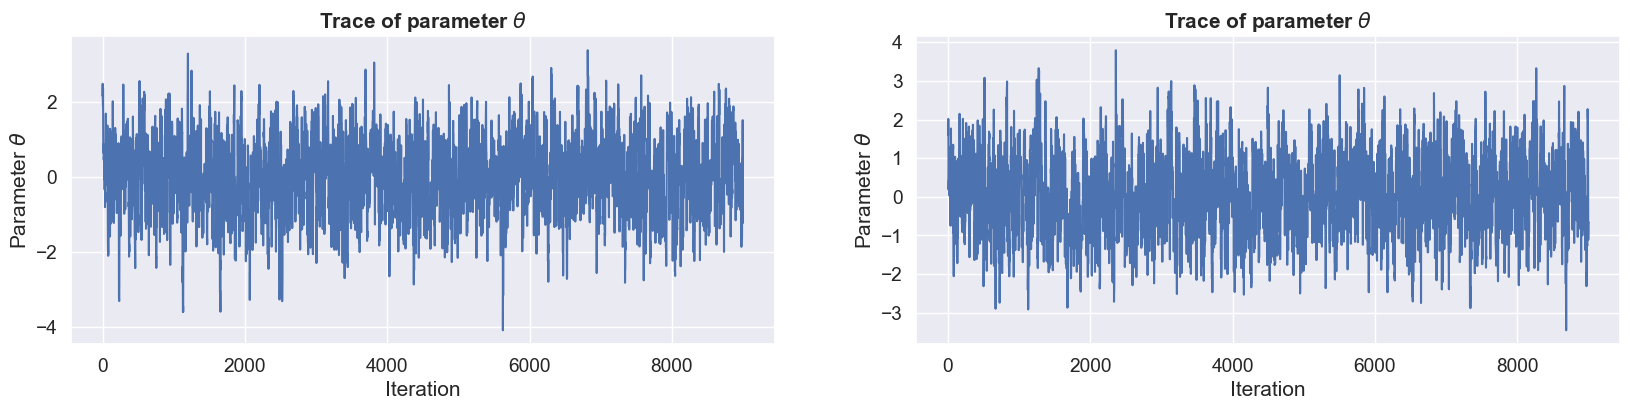

In [190]:
MCMC.plot_trace()

## Question 5.2:

In [195]:
X_train = jnp.array(2)
fstar_values = f(MCMC.post_warmup_thetas.T)
jnp.mean(fstar_values > 1)

Array(0.20397733, dtype=float32)

## Question 5.3

In [197]:
samples = np.random.normal(f(MCMC.post_warmup_thetas.T), jnp.sqrt(sigma2))
jnp.percentile(samples, jnp.array([2.5, 97.5])), jnp.mean(samples)

(Array([-2.75244209,  3.53454589], dtype=float64),
 Array(0.38074268, dtype=float64))